<a href="https://colab.research.google.com/github/tishact7/chest_xray_ai/blob/main/CWH_chest_xray_ai_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# Install gdown for downloading dataset files
!pip install -q gdown

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: GPU not detected. Go to Runtime > Change runtime type > T4 GPU')

Using device: cuda
GPU: Tesla T4


In [31]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [32]:
# Create directories
os.makedirs('data/images', exist_ok=True)

# Download the labels file
# This CSV contains labels for all 112,120 images
!pip install -q kaggle
!kaggle datasets download -f Data_Entry_2017.csv nih-chest-xrays/data -p data/ --quiet
!unzip -o -q data/Data_Entry_2017.csv.zip -d data/

# Check if labels downloaded successfully
if os.path.exists('data/Data_Entry_2017.csv'):
    labels_df = pd.read_csv('data/Data_Entry_2017.csv')
    print(f"Labels file loaded: {len(labels_df)} entries")
    print(f"Columns: {list(labels_df.columns)}")
else:
    print("ERROR: Could not download labels file.")
    print("Manual download: Go to https://nihcc.app.box.com/v/ChestXray-NIHCC")
    print("Download Data_Entry_2017_v2020.csv and upload to data/ folder")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
Labels file loaded: 112120 entries
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


In [33]:
# Download a sample batch of X-ray images
# The NIH dataset is split into 12 batches. We'll download batch 1 (~4,999 images, ~1GB)
# This may take 5-10 minutes depending on connection speed

print("Downloading X-ray images (batch 1 of 12, about 1GB)...")
print("This will take a few minutes. Be patient.\n")

!wget -q "https://nihcc.box.com/shared/static/vfk49d74nhbxq3nqjg0900w5nvkorp5c.gz" -O data/images_001.tar.gz 2>/dev/null

# Extract the images
!tar -xzf data/images_001.tar.gz -C data/ 2>/dev/null
!mv data/images/* data/images/ 2>/dev/null || true

# Count how many images we have
image_files = [f for f in os.listdir('data/images') if f.endswith('.png')]
print(f"Downloaded {len(image_files)} X-ray images")

# Clean up the tar file to save space
!rm -f data/images_001.tar.gz

This will take a few minutes. Be patient.

Downloaded 4999 X-ray images


In [34]:
# Look at the first few rows of the labels
print("First 5 rows of the labels file:\n")
print(labels_df[['Image Index', 'Finding Labels', 'Patient Age', 'Patient Gender']].head(10))
print(f"\nTotal images in full dataset: {len(labels_df)}")

First 5 rows of the labels file:

        Image Index          Finding Labels  Patient Age Patient Gender
0  00000001_000.png            Cardiomegaly           58              M
1  00000001_001.png  Cardiomegaly|Emphysema           58              M
2  00000001_002.png   Cardiomegaly|Effusion           58              M
3  00000002_000.png              No Finding           81              M
4  00000003_000.png                  Hernia           81              F
5  00000003_001.png                  Hernia           74              F
6  00000003_002.png                  Hernia           75              F
7  00000003_003.png     Hernia|Infiltration           76              F
8  00000003_004.png                  Hernia           77              F
9  00000003_005.png                  Hernia           78              F

Total images in full dataset: 112120


In [35]:
# Filter labels to only include images we actually downloaded
available_images = set(os.listdir('data/images'))
df = labels_df[labels_df['Image Index'].isin(available_images)].copy()
print(f"Images we downloaded: {len(df)}")

# Look at the distribution of conditions
# Some images have multiple conditions separated by "|"
all_findings = []
for findings in df['Finding Labels']:
    all_findings.extend(findings.split('|'))

finding_counts = Counter(all_findings)
print(f"\nCondition distribution:")
for condition, count in finding_counts.most_common():
    print(f"  {condition}: {count}")

Images we downloaded: 4999

Condition distribution:
  No Finding: 2754
  Infiltration: 830
  Effusion: 487
  Atelectasis: 460
  Nodule: 214
  Consolidation: 205
  Pneumothorax: 199
  Cardiomegaly: 196
  Fibrosis: 172
  Pleural_Thickening: 165
  Mass: 161
  Emphysema: 125
  Edema: 90
  Pneumonia: 65
  Hernia: 27


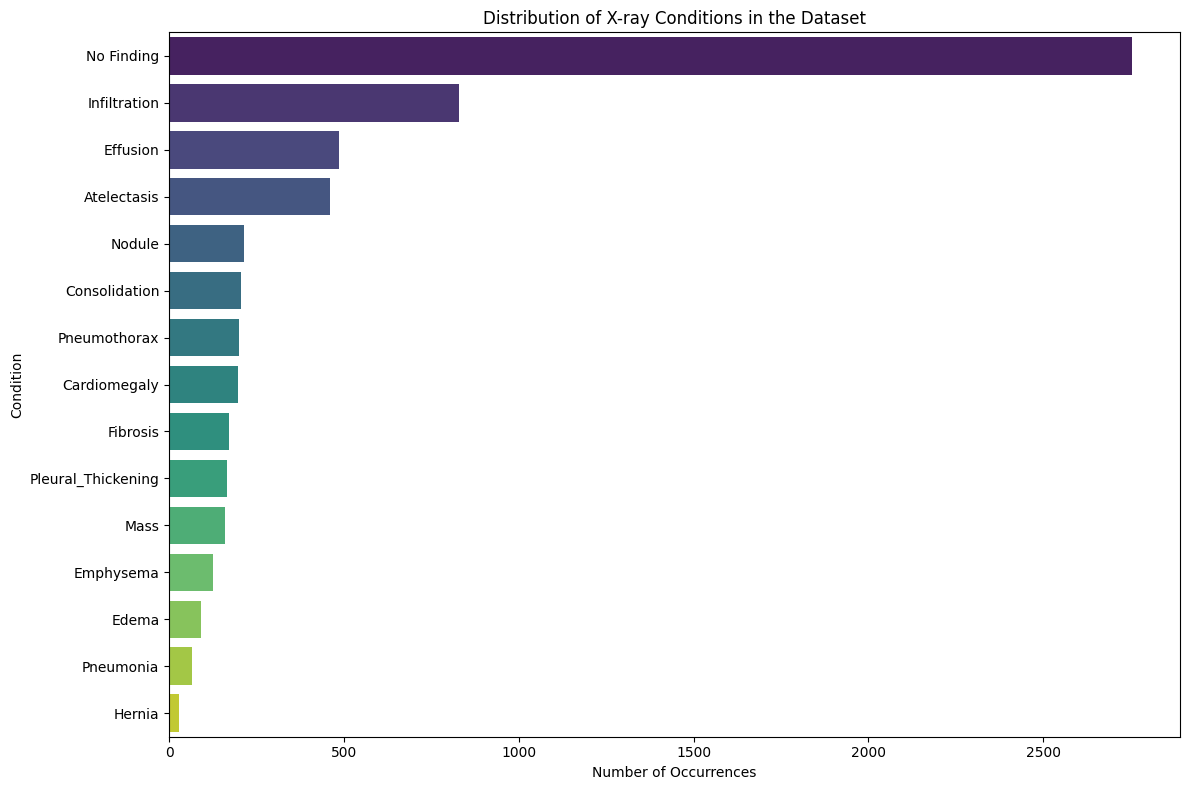

In [36]:
import seaborn as sns

# Prepare data for plotting
conditions = [item[0] for item in finding_counts.most_common()]
counts = [item[1] for item in finding_counts.most_common()]

# Create the bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=conditions, palette='viridis')
plt.title('Distribution of X-ray Conditions in the Dataset')
plt.xlabel('Number of Occurrences')
plt.ylabel('Condition')
plt.tight_layout()
plt.show()

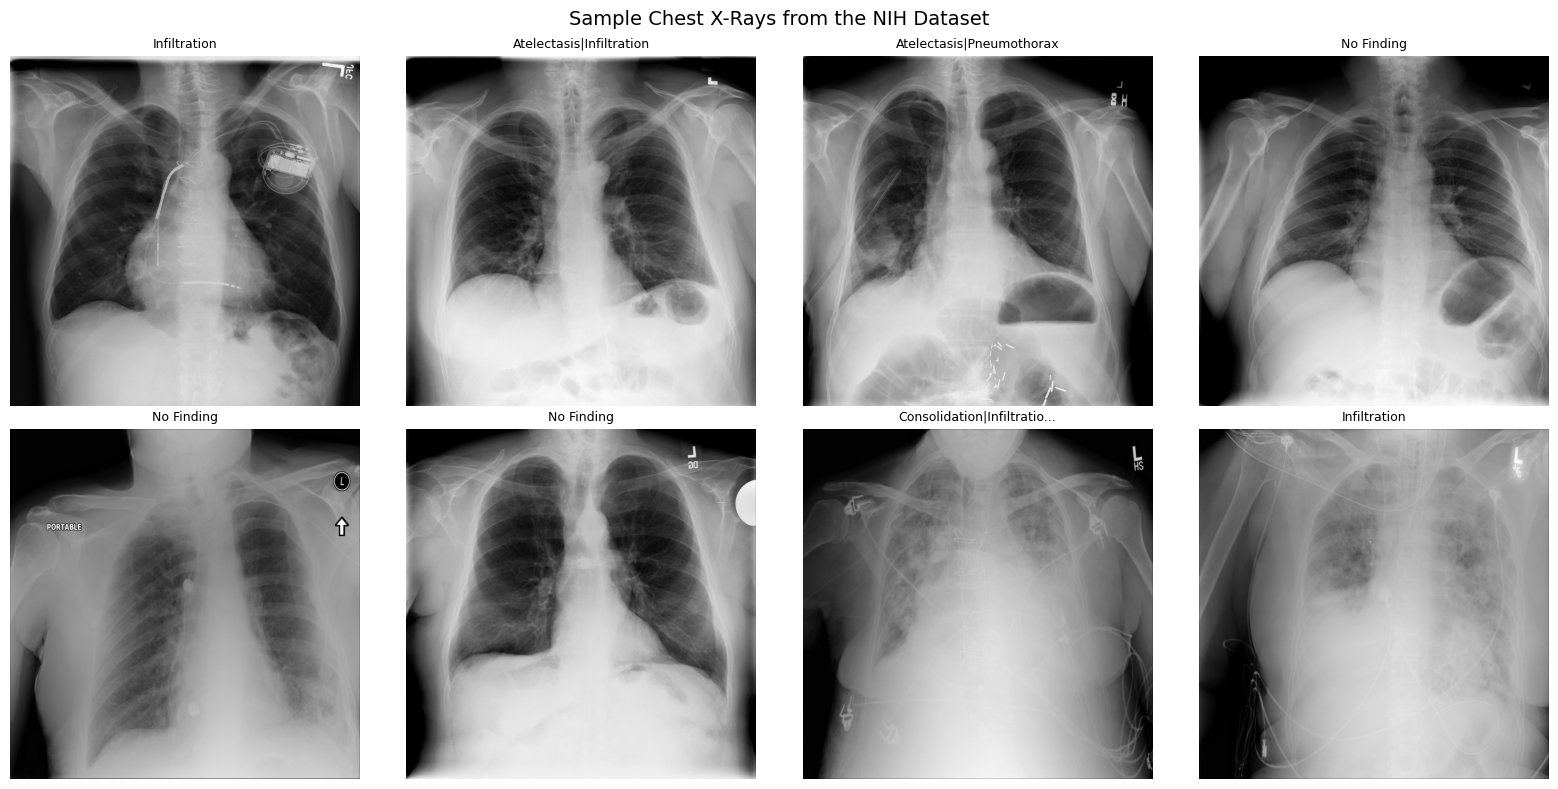

In [37]:
# Visualize some sample X-rays
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Rays from the NIH Dataset', fontsize=14)

sample_images = df.sample(8, random_state=42)
for idx, (_, row) in enumerate(sample_images.iterrows()):
    ax = axes[idx // 4][idx % 4]
    img_path = os.path.join('data/images', row['Image Index'])
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    # Truncate long labels for display
    label = row['Finding Labels']
    if len(label) > 25:
        label = label[:25] + '...'
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [38]:
# Define the 14 conditions we're classifying
# These are the conditions labeled in the NIH dataset (excluding "No Finding")
CONDITIONS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

print(f"Number of conditions to classify: {len(CONDITIONS)}")
print(f"Conditions: {CONDITIONS}")

Number of conditions to classify: 14
Conditions: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [39]:
# Create the binary label matrix
# For each image, create a list of 14 zeros and ones

def encode_labels(finding_labels):
    """Convert a string like 'Atelectasis|Effusion' into a binary vector."""
    labels = np.zeros(len(CONDITIONS), dtype=np.float32)
    for i, condition in enumerate(CONDITIONS):
        if condition in finding_labels:
            labels[i] = 1.0
    return labels

# Apply to every row
df['encoded_labels'] = df['Finding Labels'].apply(encode_labels)

# Verify: show an example
example_row = df[df['Finding Labels'] != 'No Finding'].iloc[0]
print(f"Image: {example_row['Image Index']}")
print(f"Finding Labels: {example_row['Finding Labels']}")
print(f"Encoded: {example_row['encoded_labels']}")
print(f"Active conditions: {[CONDITIONS[i] for i, v in enumerate(example_row['encoded_labels']) if v == 1]}")

Image: 00000001_000.png
Finding Labels: Cardiomegaly
Encoded: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Active conditions: ['Cardiomegaly']


In [40]:
class ChestXrayDataset(Dataset):
    """Custom dataset for loading NIH Chest X-rays."""

    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get the image filename and labels
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_dir, row['Image Index'])
        labels = row['encoded_labels']

        # Load the image
        image = Image.open(img_path).convert('RGB')  # Convert grayscale to RGB

        # Apply transformations (resize, normalize, etc.)
        if self.transform:
            image = self.transform(image)

        return image, torch.FloatTensor(labels)

print("Dataset class created successfully")

Dataset class created successfully


In [41]:
# Define image transformations
# Training: add random augmentations to help the model generalize
train_transform = transforms.Compose([
    transforms.Resize(256),              # Resize to slightly larger than 224
    transforms.RandomCrop(224),           # Randomly crop to 224x224 (adds variation)
    transforms.RandomHorizontalFlip(),    # Randomly flip left-right (X-rays can be mirrored)
    transforms.ToTensor(),               # Convert image to PyTorch tensor (0-1 range)
    transforms.Normalize(                # Normalize with ImageNet statistics
        mean=[0.485, 0.456, 0.406],      # These exact numbers are required because
        std=[0.229, 0.224, 0.225]        # DenseNet was trained with these values
    )
])

# Validation/Test: no augmentations, just resize and normalize
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),           # Center crop instead of random crop
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined")

Transforms defined


In [42]:
# Split the data: 80% training, 10% validation, 10% test
full_dataset = ChestXrayDataset(df, 'data/images', transform=None)  # No transform yet

total = len(full_dataset)
train_size = int(0.8 * total)
val_size = int(0.1 * total)
test_size = total - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Fixed seed for reproducibility
)

# Create separate datasets with appropriate transforms
train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)
test_df = df.iloc[list(test_indices.indices)].reset_index(drop=True)

train_dataset = ChestXrayDataset(train_df, 'data/images', transform=train_transform)
val_dataset = ChestXrayDataset(val_df, 'data/images', transform=eval_transform)
test_dataset = ChestXrayDataset(test_df, 'data/images', transform=eval_transform)

print(f"Training set: {len(train_dataset)} images")
print(f"Validation set: {len(val_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

Training set: 3999 images
Validation set: 499 images
Test set: 501 images


In [43]:
# Create DataLoaders
# batch_size=32 means the model sees 32 images at a time before updating its weights
# num_workers=2 means 2 background processes load images while the GPU trains

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify a batch loads correctly
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")     # Should be [32, 3, 224, 224]
print(f"Labels shape: {labels.shape}")     # Should be [32, 14]
print(f"Label example: {labels[0]}")       # Binary vector for first image

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 14])
Label example: tensor([1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0.])


In [44]:
# Load DenseNet-121 with pretrained ImageNet weights
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Look at the original final layer
print(f"Original classifier: {model.classifier}")
print(f"It outputs {model.classifier.out_features} categories (ImageNet)")

# Replace the final layer for our 14 conditions
# DenseNet-121's classifier input size is 1024
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, len(CONDITIONS))

print(f"\nNew classifier: {model.classifier}")
print(f"Now outputs {len(CONDITIONS)} categories (chest conditions)")

# Move model to GPU
model = model.to(device)
print(f"\nModel loaded on {device}")

Original classifier: Linear(in_features=1024, out_features=1000, bias=True)
It outputs 1000 categories (ImageNet)

New classifier: Linear(in_features=1024, out_features=14, bias=True)
Now outputs 14 categories (chest conditions)

Model loaded on cuda


In [45]:
# Freeze all layers except the classifier
# This means only the final layer will be updated during training
# Everything else keeps its ImageNet knowledge intact

for param in model.parameters():
    param.requires_grad = False  # Don't update these weights

# Unfreeze the classifier (the layer we just replaced)
for param in model.classifier.parameters():
    param.requires_grad = True  # Do update these weights

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")
print(f"\nYou're only training {trainable_params/total_params*100:.2f}% of the model")

Total parameters: 6,968,206
Trainable parameters: 14,350
Frozen parameters: 6,953,856

You're only training 0.21% of the model


In [46]:
# Set up training components

# Loss function: BCEWithLogitsLoss for multi-label classification
# "WithLogits" means it applies sigmoid internally, which is more numerically stable
criterion = nn.BCEWithLogitsLoss()

# Optimizer: Adam is a widely used optimizer that adapts learning rates automatically
# lr=0.001 means each weight update is small, which prevents overshooting
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Learning rate scheduler: reduces learning rate when validation loss stops improving
# This helps the model fine-tune as it gets closer to optimal performance
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)

NUM_EPOCHS = 5
print("Training setup complete")
print(f"Loss function: BCEWithLogitsLoss (for multi-label classification)")
print(f"Optimizer: Adam (learning rate = 0.001)")
print(f"Epochs: {NUM_EPOCHS}")

Training setup complete
Loss function: BCEWithLogitsLoss (for multi-label classification)
Optimizer: Adam (learning rate = 0.001)
Epochs: 5


In [47]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train the model for one epoch and return the average loss."""
    model.train()  # Set model to training mode
    running_loss = 0.0
    num_batches = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: model makes predictions
        outputs = model(images)

        # Calculate loss: how wrong were the predictions?
        loss = criterion(outputs, labels)

        # Backward pass: calculate gradients (how to adjust each weight)
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update weights

        running_loss += loss.item()
        num_batches += 1

        # Print progress every 25 batches
        if (batch_idx + 1) % 25 == 0:
            print(f"  Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    return running_loss / num_batches


def validate(model, val_loader, criterion, device):
    """Evaluate the model on the validation set."""
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    running_loss = 0.0
    all_outputs = []
    all_labels = []

    with torch.no_grad():  # Don't calculate gradients during validation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Apply sigmoid to get probabilities (0 to 1)
            probs = torch.sigmoid(outputs)
            all_outputs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_outputs = np.concatenate(all_outputs)
    all_labels = np.concatenate(all_labels)

    # Calculate ROC-AUC for conditions that have both positive and negative examples
    aucs = []
    for i, condition in enumerate(CONDITIONS):
        if len(np.unique(all_labels[:, i])) > 1:  # Need both 0s and 1s
            auc = roc_auc_score(all_labels[:, i], all_outputs[:, i])
            aucs.append(auc)

    mean_auc = np.mean(aucs) if aucs else 0.0
    avg_loss = running_loss / len(val_loader)

    return avg_loss, mean_auc

print("Training and validation functions defined")

Training and validation functions defined


In [48]:
# Train the model
print("=" * 60)
print("TRAINING STARTED")
print("=" * 60)

best_val_auc = 0.0
train_losses = []
val_losses = []
val_aucs = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 40)

    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    # Validate
    val_loss, val_auc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Mean AUC: {val_auc:.4f}")

    # Save the best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  >> New best model saved (AUC: {val_auc:.4f})")

print("\n" + "=" * 60)
print(f"Training complete. Best validation AUC: {best_val_auc:.4f}")
print("=" * 60)

TRAINING STARTED

Epoch 1/5
----------------------------------------
  Batch 25/125, Loss: 0.1775
  Batch 50/125, Loss: 0.1744
  Batch 75/125, Loss: 0.1790
  Batch 100/125, Loss: 0.2019
  Batch 125/125, Loss: 0.1616
  Train Loss: 0.1975
  Val Loss: 0.1753
  Val Mean AUC: 0.6024
  >> New best model saved (AUC: 0.6024)

Epoch 2/5
----------------------------------------
  Batch 25/125, Loss: 0.1388
  Batch 50/125, Loss: 0.1943
  Batch 75/125, Loss: 0.1826
  Batch 100/125, Loss: 0.1496
  Batch 125/125, Loss: 0.1495
  Train Loss: 0.1732
  Val Loss: 0.1713
  Val Mean AUC: 0.6609
  >> New best model saved (AUC: 0.6609)

Epoch 3/5
----------------------------------------
  Batch 25/125, Loss: 0.2071
  Batch 50/125, Loss: 0.1605
  Batch 75/125, Loss: 0.1759
  Batch 100/125, Loss: 0.1608
  Batch 125/125, Loss: 0.1934
  Train Loss: 0.1684
  Val Loss: 0.1711
  Val Mean AUC: 0.6923
  >> New best model saved (AUC: 0.6923)

Epoch 4/5
----------------------------------------
  Batch 25/125, Loss: 0.1

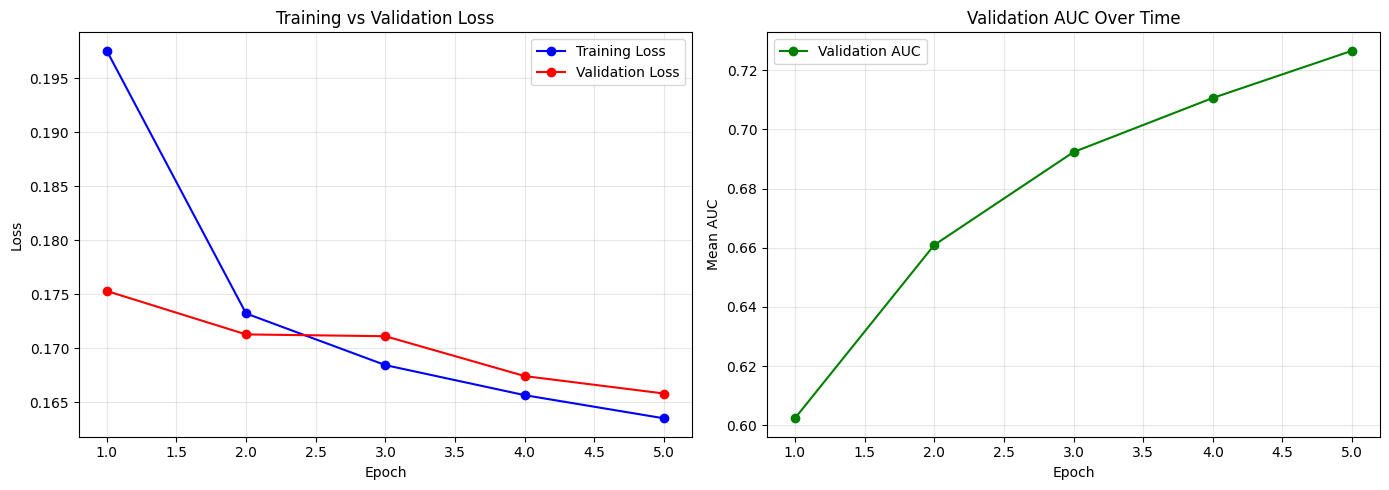

In [49]:
# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-o', label='Training Loss')
ax1.plot(range(1, NUM_EPOCHS + 1), val_losses, 'r-o', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AUC plot
ax2.plot(range(1, NUM_EPOCHS + 1), val_aucs, 'g-o', label='Validation AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean AUC')
ax2.set_title('Validation AUC Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Use a much smaller learning rate for fine-tuning
# 10x smaller than initial training
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1
)

FINETUNE_EPOCHS = 3
print(f"Fine-tuning all {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Learning rate: 0.0001 (10x smaller than initial training)")
print(f"Epochs: {FINETUNE_EPOCHS}")

Fine-tuning all 6,968,206 parameters
Learning rate: 0.0001 (10x smaller than initial training)
Epochs: 3


In [51]:
# Fine-tune the model
print("=" * 60)
print("FINE-TUNING STARTED")
print("=" * 60)

for epoch in range(FINETUNE_EPOCHS):
    print(f"\nFine-tune Epoch {epoch + 1}/{FINETUNE_EPOCHS}")
    print("-" * 40)

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    scheduler.step(val_loss)

    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Mean AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  >> New best model saved (AUC: {val_auc:.4f})")

print("\n" + "=" * 60)
print(f"Fine-tuning complete. Best AUC: {best_val_auc:.4f}")
print("=" * 60)

FINE-TUNING STARTED

Fine-tune Epoch 1/3
----------------------------------------
  Batch 25/125, Loss: 0.1945
  Batch 50/125, Loss: 0.1630
  Batch 75/125, Loss: 0.1717
  Batch 100/125, Loss: 0.1520
  Batch 125/125, Loss: 0.1249
  Train Loss: 0.1591
  Val Loss: 0.1583
  Val Mean AUC: 0.7763
  >> New best model saved (AUC: 0.7763)

Fine-tune Epoch 2/3
----------------------------------------
  Batch 25/125, Loss: 0.1500
  Batch 50/125, Loss: 0.1544
  Batch 75/125, Loss: 0.1525
  Batch 100/125, Loss: 0.1236
  Batch 125/125, Loss: 0.1360
  Train Loss: 0.1466
  Val Loss: 0.1534
  Val Mean AUC: 0.7588

Fine-tune Epoch 3/3
----------------------------------------
  Batch 25/125, Loss: 0.1170
  Batch 50/125, Loss: 0.1112
  Batch 75/125, Loss: 0.1239
  Batch 100/125, Loss: 0.1474
  Batch 125/125, Loss: 0.1049
  Train Loss: 0.1358
  Val Loss: 0.1528
  Val Mean AUC: 0.7845
  >> New best model saved (AUC: 0.7845)

Fine-tuning complete. Best AUC: 0.7845


In [52]:
# Load the best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Get predictions on the test set
all_outputs = []
all_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_outputs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_outputs = np.concatenate(all_outputs)
all_labels = np.concatenate(all_labels)

# Calculate ROC-AUC for each condition
print("ROC-AUC per condition:")
print("-" * 40)
auc_scores = {}
for i, condition in enumerate(CONDITIONS):
    if len(np.unique(all_labels[:, i])) > 1:
        auc = roc_auc_score(all_labels[:, i], all_outputs[:, i])
        auc_scores[condition] = auc
        status = "excellent" if auc > 0.9 else "good" if auc > 0.8 else "fair" if auc > 0.7 else "needs improvement"
        print(f"  {condition:25s} AUC: {auc:.4f} ({status})")
    else:
        print(f"  {condition:25s} Not enough positive cases to evaluate")

if auc_scores:
    print(f"\n  {'Mean AUC':25s} {np.mean(list(auc_scores.values())):.4f}")

ROC-AUC per condition:
----------------------------------------
  Atelectasis               AUC: 0.7150 (fair)
  Cardiomegaly              AUC: 0.8752 (good)
  Consolidation             AUC: 0.8166 (good)
  Edema                     AUC: 0.9746 (excellent)
  Effusion                  AUC: 0.8239 (good)
  Emphysema                 AUC: 0.8190 (good)
  Fibrosis                  AUC: 0.7091 (fair)
  Hernia                    AUC: 0.9960 (excellent)
  Infiltration              AUC: 0.7223 (fair)
  Mass                      AUC: 0.7867 (fair)
  Nodule                    AUC: 0.6703 (needs improvement)
  Pleural_Thickening        AUC: 0.7332 (fair)
  Pneumonia                 AUC: 0.8532 (good)
  Pneumothorax              AUC: 0.9091 (excellent)

  Mean AUC                  0.8146


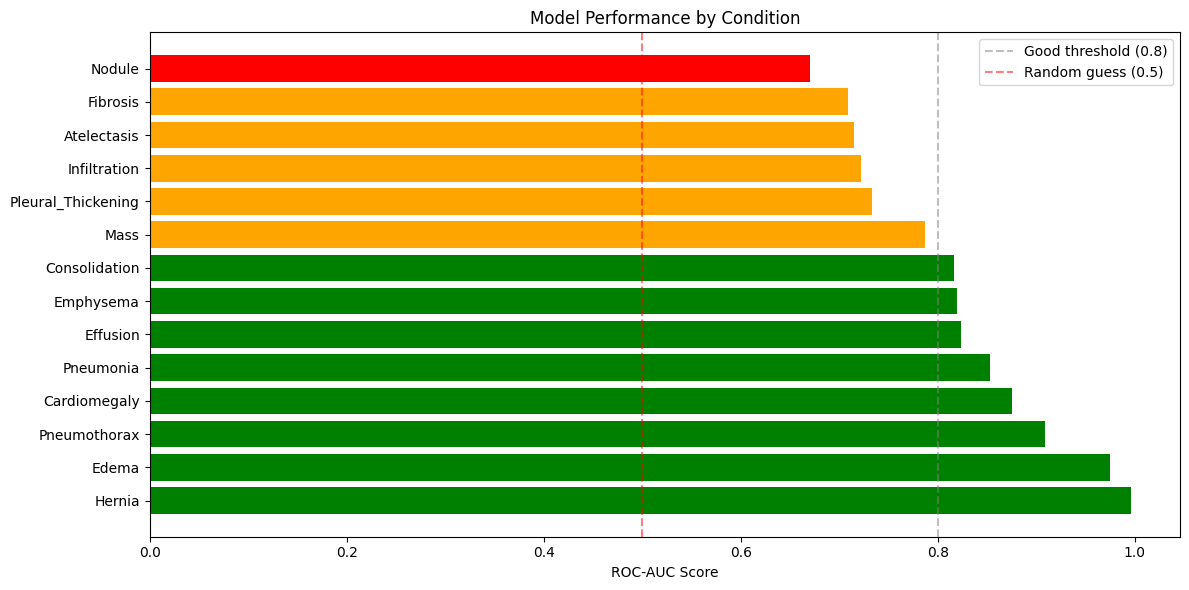

In [53]:
# Visualize ROC-AUC scores as a bar chart
if auc_scores:
    conditions = list(auc_scores.keys())
    scores = list(auc_scores.values())

    # Sort by AUC score
    sorted_pairs = sorted(zip(conditions, scores), key=lambda x: x[1], reverse=True)
    conditions, scores = zip(*sorted_pairs)

    # Color bars based on performance
    colors = ['green' if s > 0.8 else 'orange' if s > 0.7 else 'red' for s in scores]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(range(len(conditions)), scores, color=colors)
    plt.yticks(range(len(conditions)), conditions)
    plt.xlabel('ROC-AUC Score')
    plt.title('Model Performance by Condition')
    plt.axvline(x=0.8, color='gray', linestyle='--', alpha=0.5, label='Good threshold (0.8)')
    plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess (0.5)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [54]:
# Generate predictions using 0.5 threshold
predictions = (all_outputs > 0.5).astype(int)

# Classification report for conditions with enough samples
print("Detailed Classification Report:")
print("=" * 60)
for i, condition in enumerate(CONDITIONS):
    pos_count = int(all_labels[:, i].sum())
    pred_count = int(predictions[:, i].sum())
    if pos_count > 0:
        from sklearn.metrics import precision_score, recall_score, f1_score
        precision = precision_score(all_labels[:, i], predictions[:, i], zero_division=0)
        recall = recall_score(all_labels[:, i], predictions[:, i], zero_division=0)
        f1 = f1_score(all_labels[:, i], predictions[:, i], zero_division=0)
        print(f"  {condition:25s} Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}  (True positives: {pos_count})")

Detailed Classification Report:
  Atelectasis               Precision: 0.500  Recall: 0.036  F1: 0.067  (True positives: 56)
  Cardiomegaly              Precision: 0.667  Recall: 0.154  F1: 0.250  (True positives: 26)
  Consolidation             Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 20)
  Edema                     Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 8)
  Effusion                  Precision: 0.562  Recall: 0.327  F1: 0.414  (True positives: 55)
  Emphysema                 Precision: 0.333  Recall: 0.056  F1: 0.095  (True positives: 18)
  Fibrosis                  Precision: 0.667  Recall: 0.125  F1: 0.211  (True positives: 16)
  Hernia                    Precision: 0.000  Recall: 0.000  F1: 0.000  (True positives: 2)
  Infiltration              Precision: 0.412  Recall: 0.090  F1: 0.147  (True positives: 78)
  Mass                      Precision: 0.500  Recall: 0.067  F1: 0.118  (True positives: 15)
  Nodule                    Precision: 0

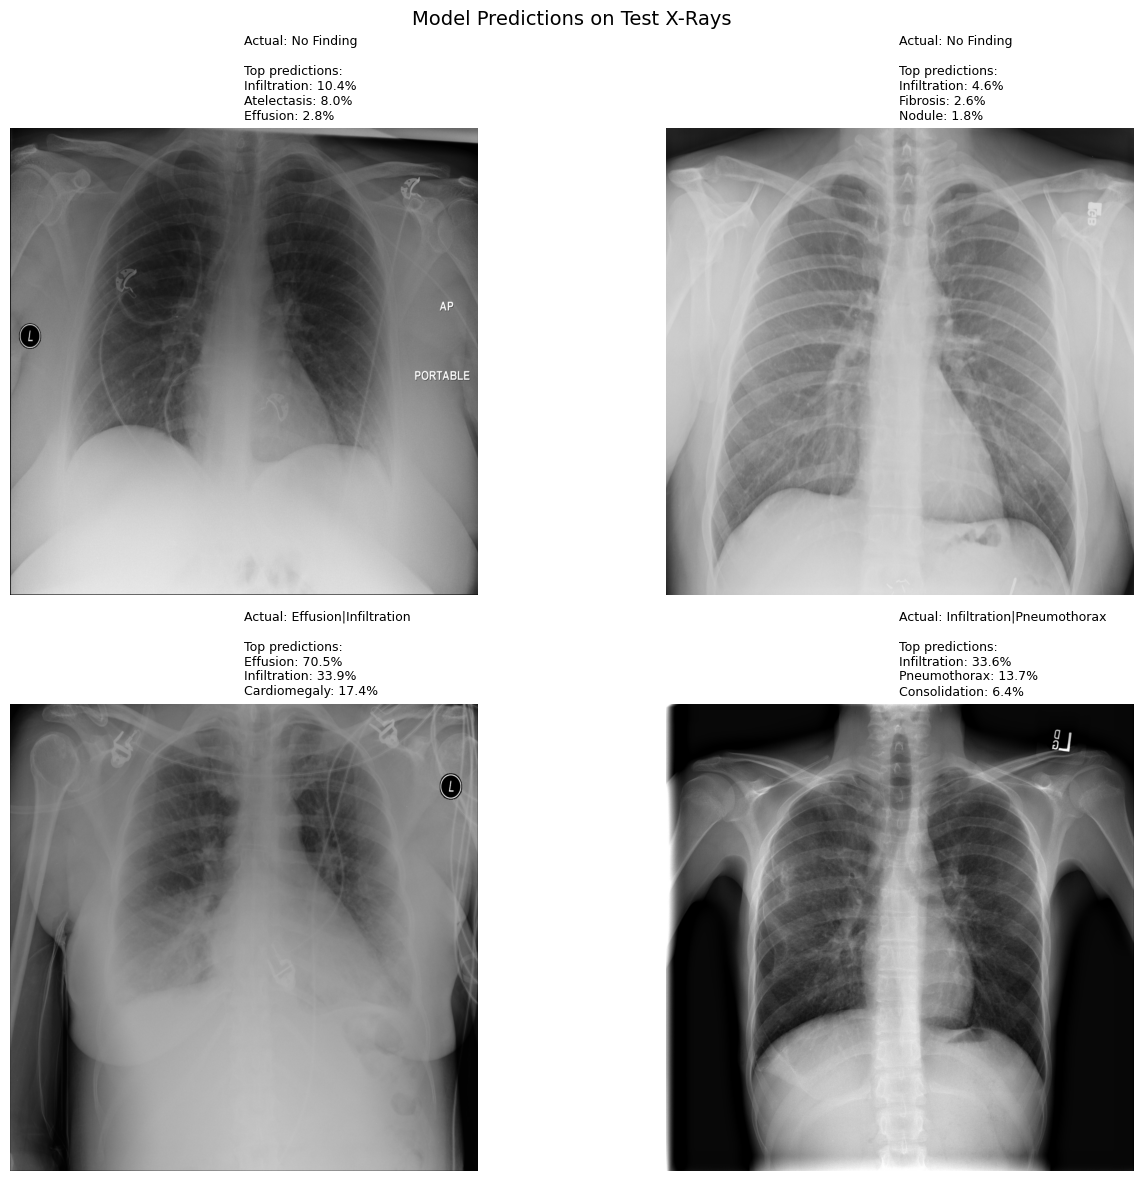

In [55]:
def predict_single_image(model, image_path, transform, device):
    """Load a single X-ray image and predict conditions."""
    # Load and transform the image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Get predictions
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.sigmoid(output).cpu().numpy()[0]

    return image, probabilities


# Pick 4 random test images and show predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sample_test = test_df.sample(4, random_state=123)

for idx, (_, row) in enumerate(sample_test.iterrows()):
    ax = axes[idx // 2][idx % 2]
    img_path = os.path.join('data/images', row['Image Index'])

    image, probs = predict_single_image(model, img_path, eval_transform, device)

    # Display the X-ray
    ax.imshow(image, cmap='gray')

    # Show top 3 predictions
    top_indices = np.argsort(probs)[::-1][:3]
    pred_text = "\n".join([f"{CONDITIONS[i]}: {probs[i]:.1%}" for i in top_indices])
    actual = row['Finding Labels']

    ax.set_title(f"Actual: {actual}\n\nTop predictions:\n{pred_text}", fontsize=9, ha='left')
    ax.axis('off')

plt.suptitle('Model Predictions on Test X-Rays', fontsize=14)
plt.tight_layout()
plt.show()